# India Trade Deficit Forecasting
Predicts next month's trade deficit using lag features, rolling statistics, macro indicators, and regime flags.

## 1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import joblib

## 2. Evaluation Helper

In [4]:
def evaluate(y_true, y_pred, name, naive=None):
    """Print MAE, RMSE, R² and optionally compare to naive lag-1 baseline."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name:30s} -> MAE: {mae/1e9:.3f}B  RMSE: {rmse/1e9:.3f}B  R²: {r2:.4f}")
    if naive is not None:
        naive_mae = mean_absolute_error(y_true, naive)
        print(f"{'  Naive lag-1 baseline':30s} -> MAE: {naive_mae/1e9:.3f}B")


## 3. Load & Sort Data

In [5]:
df = pd.read_csv('final_dataset_2011_2025.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Drop the pre-computed target column from CSV — we'll make it ourselves cleanly
if 'trade_deficit_next' in df.columns:
    df = df.drop(columns=['trade_deficit_next'])

print(f"Loaded {len(df)} rows | {df['date'].min().date()} to {df['date'].max().date()}")
print(df.head(3))


Loaded 177 rows | 2011-01-01 to 2025-09-01
        date  imports_russia  exports_russia  imports_china  exports_china  \
0 2011-01-01    2.446505e+08    1.212995e+08   3.914855e+09   1.274883e+09   
1 2011-02-01    2.240527e+08    1.398739e+08   3.365378e+09   1.281265e+09   
2 2011-03-01    2.158187e+08    3.072053e+08   3.131303e+09   1.044168e+09   

    imports_usa   exports_usa  oil_price    usd_inr  gdp_india  gdp_russia  \
0  1.654156e+09  2.218182e+09      96.52  45.838001       1.82        2.05   
1  1.608560e+09  2.295311e+09     103.72  45.250000       1.82        2.05   
2  1.340221e+09  2.997881e+09     114.64  44.610001       1.82        2.05   

   gdp_china  gdp_usa  trade_deficit  
0       7.67     15.6   2.199297e+09  
1       7.67     15.6   1.481540e+09  
2       7.67     15.6   3.380881e+08  


## 4. Target Variable

In [6]:
# Target: next month's trade deficit
df['trade_deficit_next'] = df['trade_deficit'].shift(-1)
print("Sample target values:")
print(df[['date', 'trade_deficit', 'trade_deficit_next']].head(5))


Sample target values:
        date  trade_deficit  trade_deficit_next
0 2011-01-01   2.199297e+09        1.481540e+09
1 2011-02-01   1.481540e+09        3.380881e+08
2 2011-03-01   3.380881e+08        1.589569e+09
3 2011-04-01   1.589569e+09        3.439358e+09
4 2011-05-01   3.439358e+09        3.319808e+09


## 5. Feature Engineering

In [7]:
# --- Lag features (trade deficit & Russia imports) ---
lags = [1, 2, 3, 6, 9, 12, 18, 24]
for lag in lags:
    df[f'td_lag_{lag}']     = df['trade_deficit'].shift(lag)
    df[f'import_lag_{lag}'] = df['imports_russia'].shift(lag)

# --- China & USA import lags (key drivers beyond Russia) ---
for lag in [1, 2, 3, 6, 12]:
    df[f'imports_china_lag_{lag}'] = df['imports_china'].shift(lag)
    df[f'imports_usa_lag_{lag}']   = df['imports_usa'].shift(lag)

# --- Rolling statistics (shift(1) to avoid leakage) ---
df['td_roll_mean_3']  = df['trade_deficit'].shift(1).rolling(3).mean()
df['td_roll_std_3']   = df['trade_deficit'].shift(1).rolling(3).std()
df['td_roll_mean_6']  = df['trade_deficit'].shift(1).rolling(6).mean()
df['td_roll_mean_12'] = df['trade_deficit'].shift(1).rolling(12).mean()

# --- Exponentially weighted means (better at tracking regime level) ---
df['td_ewm_3']  = df['trade_deficit'].shift(1).ewm(span=3).mean()
df['td_ewm_6']  = df['trade_deficit'].shift(1).ewm(span=6).mean()
df['td_ewm_12'] = df['trade_deficit'].shift(1).ewm(span=12).mean()

# Ratio: short-term vs long-term trend (> 1 = accelerating deficit)
df['ewm_ratio'] = df['td_ewm_3'] / df['td_ewm_12'].replace(0, np.nan)

# --- Year-over-year change ---
df['td_yoy_change'] = df['trade_deficit'].shift(1) - df['trade_deficit'].shift(13)

# --- Seasonality (cyclical encoding, avoids ordinal assumption) ---
df['month']     = df['date'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# --- Macro: nonlinear terms & interaction ---
df['usd_squared']         = df['usd_inr'] ** 2
df['oil_squared']         = df['oil_price'] ** 2
df['usd_oil_interaction'] = df['usd_inr'] * df['oil_price']

# --- First differences (stationarity helpers) ---
df['td_diff']  = df['trade_deficit'].diff()
df['usd_diff'] = df['usd_inr'].diff()
df['oil_diff'] = df['oil_price'].diff()

# --- Regime flags ---
df['covid_flag'] = (df['date'] >= '2020-03-01').astype(int)
df['war_flag']   = (df['date'] >= '2022-02-01').astype(int)

# War intensity ramp: captures the fact that deficit kept growing AFTER war started
war_start = pd.Timestamp('2022-02-01')
df['months_since_war'] = ((df['date'] - war_start) / pd.Timedelta('30D')).clip(lower=0)

print(f"Features created. DataFrame shape: {df.shape}")


Features created. DataFrame shape: (177, 62)


## 6. Drop NaNs & Split

In [8]:
df = df.dropna().reset_index(drop=True)

# Note: 'year' is intentionally excluded — it caused overfitting (41% importance
# in XGBoost but doesn't generalise to unseen future years)
# GDP columns excluded — annual frequency interpolated into monthly is misleading
EXCLUDE = [
    'date', 'trade_deficit_next', 'month',      # identifiers / raw target / redundant
    'year',                                       # overfits to year identity
    'trade_deficit',                              # raw current value — all lags already encode it
    'gdp_india', 'gdp_usa', 'gdp_china', 'gdp_russia'  # annual, low signal
]

features = [col for col in df.columns if col not in EXCLUDE]
print(f"Number of features: {len(features)}")
print(features)

# Time-based split:
#   Train  → up to end of 2023  (includes the 2022-23 spike)
#   Val    → H1 2024            (used for early stopping)
#   Test   → H2 2024 onwards    (held-out evaluation)
train = df[df['date'] < '2024-01-01']
val   = df[(df['date'] >= '2024-01-01') & (df['date'] < '2024-07-01')]
test  = df[df['date'] >= '2024-07-01']

print(f"\nTrain: {len(train)} rows ({train['date'].min().date()} – {train['date'].max().date()})")
print(f"Val:   {len(val)} rows ({val['date'].min().date()} – {val['date'].max().date()})")
print(f"Test:  {len(test)} rows ({test['date'].min().date()} – {test['date'].max().date()})")

X_train, y_train = train[features], train['trade_deficit_next']
X_val,   y_val   = val[features],   val['trade_deficit_next']
X_test,  y_test  = test[features],  test['trade_deficit_next']


Number of features: 54
['imports_russia', 'exports_russia', 'imports_china', 'exports_china', 'imports_usa', 'exports_usa', 'oil_price', 'usd_inr', 'td_lag_1', 'import_lag_1', 'td_lag_2', 'import_lag_2', 'td_lag_3', 'import_lag_3', 'td_lag_6', 'import_lag_6', 'td_lag_9', 'import_lag_9', 'td_lag_12', 'import_lag_12', 'td_lag_18', 'import_lag_18', 'td_lag_24', 'import_lag_24', 'imports_china_lag_1', 'imports_usa_lag_1', 'imports_china_lag_2', 'imports_usa_lag_2', 'imports_china_lag_3', 'imports_usa_lag_3', 'imports_china_lag_6', 'imports_usa_lag_6', 'imports_china_lag_12', 'imports_usa_lag_12', 'td_roll_mean_3', 'td_roll_std_3', 'td_roll_mean_6', 'td_roll_mean_12', 'td_ewm_3', 'td_ewm_6', 'td_ewm_12', 'ewm_ratio', 'td_yoy_change', 'month_sin', 'month_cos', 'usd_squared', 'oil_squared', 'usd_oil_interaction', 'td_diff', 'usd_diff', 'oil_diff', 'covid_flag', 'war_flag', 'months_since_war']

Train: 132 rows (2013-01-01 – 2023-12-01)
Val:   6 rows (2024-01-01 – 2024-06-01)
Test:  14 rows (20

## 7. Baseline — Linear Regression

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

evaluate(y_test, lr_preds, "Linear Regression", naive=X_test['td_lag_1'])


Linear Regression              -> MAE: 2.049B  RMSE: 2.669B  R²: -1.1580
  Naive lag-1 baseline         -> MAE: 2.036B


## 8. Random Forest

In [10]:
rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

evaluate(y_test, rf_preds, "Random Forest", naive=X_test['td_lag_1'])


Random Forest                  -> MAE: 1.463B  RMSE: 1.853B  R²: -0.0404
  Naive lag-1 baseline         -> MAE: 2.036B


## 9. XGBoost (with Early Stopping)

In [11]:
xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=50,   # stops if val doesn't improve for 50 rounds
    verbosity=0
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_preds = xgb.predict(X_test)
print(f"Best iteration: {xgb.best_iteration}")
evaluate(y_test, xgb_preds, "XGBoost", naive=X_test['td_lag_1'])


Best iteration: 272
XGBoost                        -> MAE: 1.724B  RMSE: 2.069B  R²: -0.2966
  Naive lag-1 baseline         -> MAE: 2.036B


In [12]:
cat_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.02,
    depth=4,
    l2_leaf_reg=10,
    random_strength=2,
    bagging_temperature=1,
    loss_function='RMSE',
    random_state=42,
    verbose=100
)

In [13]:
cat_model.fit(X_train, y_train)

cat_preds = cat_model.predict(X_test)

cat_mae = mean_absolute_error(y_test, cat_preds)
cat_rmse = np.sqrt(mean_squared_error(y_test, cat_preds))

print(f"CatBoost -> MAE: {cat_mae:.2f}, RMSE: {cat_rmse:.2f}")

0:	learn: 3005039315.1841526	total: 62.4ms	remaining: 49.9s
100:	learn: 1301850911.8719347	total: 188ms	remaining: 1.3s
200:	learn: 868227889.0805333	total: 281ms	remaining: 838ms
300:	learn: 714264276.1561604	total: 352ms	remaining: 583ms
400:	learn: 613299912.0535251	total: 437ms	remaining: 434ms
500:	learn: 516344484.2385893	total: 491ms	remaining: 293ms
600:	learn: 430536995.6384650	total: 553ms	remaining: 183ms
700:	learn: 380306841.9338012	total: 622ms	remaining: 87.8ms
799:	learn: 337366282.5307086	total: 714ms	remaining: 0us
CatBoost -> MAE: 1382939599.55, RMSE: 1798282479.38


## 10. Model Comparison Summary

In [14]:
print("=" * 65)
print(f"{'Model':<30} {'MAE (B)':>10} {'RMSE (B)':>10} {'R²':>8}")
print("=" * 65)

for name, preds in [
    ("Naive lag-1 baseline", X_test['td_lag_1'].values),
    ("Linear Regression",    lr_preds),
    ("Random Forest",        rf_preds),
    ("XGBoost",              xgb_preds),
    ("CatBoost",             cat_preds)
]:
    mae  = mean_absolute_error(y_test, preds) / 1e9
    rmse = np.sqrt(mean_squared_error(y_test, preds)) / 1e9
    r2   = r2_score(y_test, preds)
    print(f"{name:<30} {mae:>10.3f} {rmse:>10.3f} {r2:>8.4f}")

print("=" * 65)


Model                             MAE (B)   RMSE (B)       R²
Naive lag-1 baseline                2.036      2.377  -0.7115
Linear Regression                   2.049      2.669  -1.1580
Random Forest                       1.463      1.853  -0.0404
XGBoost                             1.724      2.069  -0.2966
CatBoost                            1.383      1.798   0.0204


## 13. Actual vs Predicted Plot

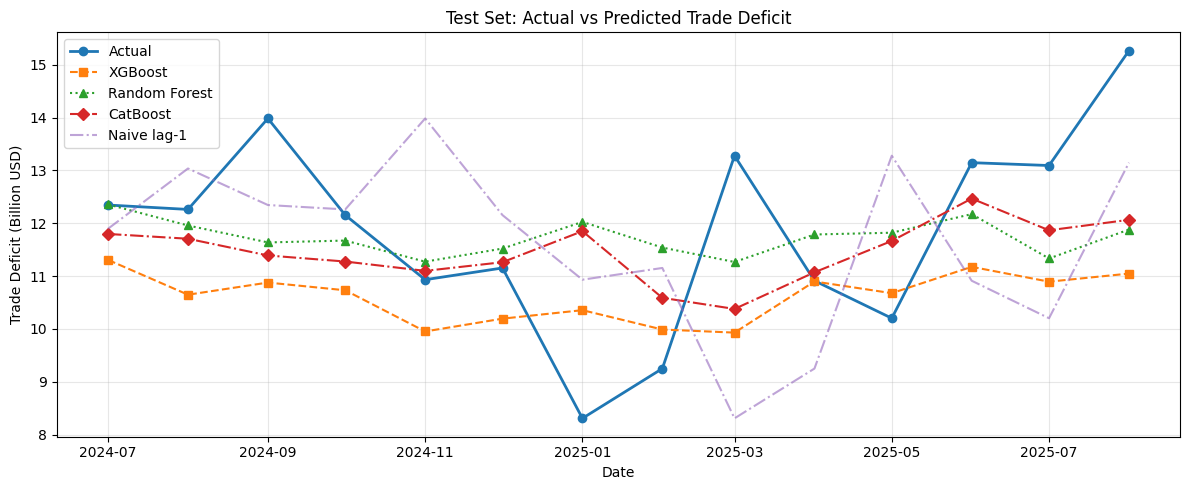

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test['date'], y_test / 1e9,       label='Actual',       marker='o', linewidth=2)
ax.plot(test['date'], xgb_preds / 1e9,    label='XGBoost',      marker='s', linestyle='--')
ax.plot(test['date'], rf_preds / 1e9,     label='Random Forest', marker='^', linestyle=':')
ax.plot(test['date'], cat_preds / 1e9,    label='CatBoost',      marker='D', linestyle='-.')
ax.plot(test['date'], X_test['td_lag_1'] / 1e9, label='Naive lag-1', linestyle='-.', alpha=0.6)
ax.set_title('Test Set: Actual vs Predicted Trade Deficit')
ax.set_ylabel('Trade Deficit (Billion USD)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [16]:
cat_model.save_model("trade_model.cbm")
joblib.dump(features, "features.pkl")

['features.pkl']